# IVF Optimization Lab

Laboratório para otimização dos parâmetros do Inverted File Index (IVF) antes de gerar os arquivos binários para a API Go.

**Objetivo**: Explicabilidade de como `n_clusters`, `batch_size` e `nprobe` afetam recall@5, latência e qualidade da busca.

**Contexto**: A API Go atual faz KNN brute-force com k=5 e threshold=0.6. O IVF vai substituir o brute-force para reduzir latência.

In [22]:
from pathlib import Path

import gzip
import ijson
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from scipy.spatial.distance import cdist
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split

optuna.logging.set_verbosity(optuna.logging.WARNING)

K_NEIGHBORS = 5          # mesmo k do Go (knn.go)
FRAUD_THRESHOLD = 0.6    # mesmo threshold do Go
RANDOM_STATE = 42

# ── Opções de dataset ──────────────────────────────────────────────────────
USE_FULL_DATASET = False  # Se True, usa todos os 3M registros; se False, usa amostragem
if USE_FULL_DATASET:
    N_SAMPLE = None       # None = carregar tudo
    VAL_SIZE = 50_000     # mais queries se temos mais dados
else:
    N_SAMPLE = 100_000    # amostras do dataset (evita carregar 320 MB)
    VAL_SIZE = 10_000     # queries de validação

print("Imports OK")


Imports OK


## 1. Carregamento completo do dataset

3M records × 14 dims ≈ 320 MB em float64 — cabe na memória sem problemas.

In [23]:
_cwd = Path.cwd()
_candidates = [
    _cwd / "data" / "references.json.gz",
    _cwd.parent / "data" / "references.json.gz",
]
DATA_PATH = next((p for p in _candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("references.json.gz não encontrado")

print(f"Carregando dados de {DATA_PATH} ...")
t0 = time.time()

rng = np.random.default_rng(RANDOM_STATE)
bucket_vecs: list[np.ndarray] = []
bucket_labels: list[bool] = []
n_seen = 0

if N_SAMPLE is None:
    # Carregar todos os registros
    print(f"Carregando TODOS os registros (dataset completo)...")
    with gzip.open(DATA_PATH, "rb") as f:
        for obj in ijson.items(f, "item"):
            vec = np.asarray(obj["vector"], dtype=np.float64)
            fraud = obj.get("label") == "fraud"
            bucket_vecs.append(vec)
            bucket_labels.append(fraud)
            if (len(bucket_vecs)) % 500_000 == 0:
                print(f"  ... {len(bucket_vecs):,} registros carregados")
else:
    # Reservoir sampling: lê o stream sem carregar tudo na memória
    print(f"Amostrando {N_SAMPLE:,} registros de {DATA_PATH} ...")
    with gzip.open(DATA_PATH, "rb") as f:
        for obj in ijson.items(f, "item"):
            n_seen += 1
            vec = np.asarray(obj["vector"], dtype=np.float64)
            fraud = obj.get("label") == "fraud"
            if len(bucket_vecs) < N_SAMPLE:
                bucket_vecs.append(vec)
                bucket_labels.append(fraud)
            else:
                j = int(rng.integers(0, n_seen))
                if j < N_SAMPLE:
                    bucket_vecs[j] = vec
                    bucket_labels[j] = fraud

vectors = np.stack(bucket_vecs)
labels = np.array(bucket_labels, dtype=bool)
del bucket_vecs, bucket_labels

elapsed = time.time() - t0
if N_SAMPLE is None:
    print(f"Dataset completo carregado em {elapsed:.1f}s  ({len(vectors):,} registros)")
else:
    print(f"Amostragem concluída em {elapsed:.1f}s  ({n_seen:,} registros vistos, {len(vectors):,} amostrados)")

print(f"Shape: {vectors.shape}, Fraudes: {labels.sum()} ({100 * labels.mean():.2f}%)")
print(f"Memória: {vectors.nbytes / 1024**2:.1f} MB")


Carregando dados de /Users/luiz/repos/rbc-2026/data/references.json.gz ...
Amostrando 100,000 registros de /Users/luiz/repos/rbc-2026/data/references.json.gz ...
Amostragem concluída em 19.3s  (3,000,000 registros vistos, 100,000 amostrados)
Shape: (100000, 14), Fraudes: 33333 (33.33%)
Memória: 10.7 MB


## 2. Split train/val + Ground Truth (Brute Force)

Calcula os 5 vizinhos mais próximos via brute-force para cada query de validação. Esse é o "gabarito" contra o qual medimos o recall do IVF.

In [24]:
# Separa um conjunto de validação
idx_all = np.arange(len(vectors))
idx_train, idx_val = train_test_split(
    idx_all, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=labels
)

X_train = vectors[idx_train]
y_train = labels[idx_train]
X_val = vectors[idx_val]
y_val = labels[idx_val]

print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Fraudes train: {y_train.sum()} ({100*y_train.mean():.2f}%)")
print(f"Fraudes val:   {y_val.sum()} ({100*y_val.mean():.2f}%)")

# Ground truth: brute-force KNN nos dados de treino
print("\nCalculando ground truth (brute-force KNN)...")
t0 = time.time()
bf = NearestNeighbors(n_neighbors=K_NEIGHBORS, algorithm="brute", metric="euclidean", n_jobs=-1)
bf.fit(X_train)
gt_dists, gt_indices = bf.kneighbors(X_val)
print(f"Ground truth calculado em {time.time() - t0:.1f}s")

# Ground truth para classificação: score = fração de vizinhos fraudulentos
gt_fraud_counts = np.array([y_train[gt_indices[i]].sum() for i in range(len(X_val))])
gt_scores = gt_fraud_counts / K_NEIGHBORS
gt_approved = gt_scores < FRAUD_THRESHOLD
print(f"Brute-force: {(~gt_approved).sum()} rejeitados de {len(X_val)} queries ({100*(~gt_approved).mean():.2f}%)")

Train: (90000, 14), Val: (10000, 14)
Fraudes train: 30000 (33.33%)
Fraudes val:   3333 (33.33%)

Calculando ground truth (brute-force KNN)...
Ground truth calculado em 0.4s
Brute-force: 3339 rejeitados de 10000 queries (33.39%)


## 3. Classe IVFExperiment

Simula exatamente o que o Go fará:
1. K-Means para quantização grosseira (centroides)
2. Lista invertida (posting lists)
3. Busca: seleciona `nprobe` centroides mais próximos → brute-force local nos candidatos

In [25]:
class IVFExperiment:
    """Simula busca IVF como implementada na API Go."""

    def __init__(self, X_train, y_train, X_val, gt_indices):
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.gt_indices = gt_indices

    def build_index(self, n_clusters, batch_size, n_init=3):
        """Treina K-Means e constrói listas invertidas."""
        self.kmeans = MiniBatchKMeans(
            n_clusters=n_clusters,
            batch_size=batch_size,
            n_init=n_init,
            random_state=RANDOM_STATE,
        )
        self.kmeans.fit(self.X_train)
        self.centroids = self.kmeans.cluster_centers_

        cluster_labels = self.kmeans.labels_
        self.inverted_lists = {
            c: np.where(cluster_labels == c)[0] for c in range(n_clusters)
        }

        sizes = [len(v) for v in self.inverted_lists.values()]
        return {
            "n_clusters": n_clusters,
            "inertia": self.kmeans.inertia_,
            "list_size_mean": np.mean(sizes),
            "list_size_std": np.std(sizes),
            "list_size_min": np.min(sizes),
            "list_size_max": np.max(sizes),
        }

    def search(self, nprobe, k=K_NEIGHBORS):
        """Busca IVF — distâncias aos centroides vetorizadas (cdist)."""
        centroids = self.centroids
        inv = self.inverted_lists
        X_train = self.X_train
        X_val = self.X_val
        gt = self.gt_indices

        # Todas as distâncias query→centroide de uma vez (n_val × n_clusters)
        dists_matrix = cdist(X_val, centroids)

        total_recall = 0.0
        total_candidates = 0
        start = time.perf_counter()

        for i in range(len(X_val)):
            nearest_c = np.argpartition(dists_matrix[i], nprobe)[:nprobe]
            candidate_ids = np.concatenate([inv[c] for c in nearest_c])
            total_candidates += len(candidate_ids)

            if len(candidate_ids) == 0:
                continue

            local_dists = np.linalg.norm(X_train[candidate_ids] - X_val[i], axis=1)
            top_k_local = candidate_ids[np.argpartition(local_dists, min(k, len(local_dists) - 1))[:k]]

            hits = len(np.intersect1d(top_k_local, gt[i]))
            total_recall += hits / k

        elapsed = time.perf_counter() - start
        n_queries = len(X_val)
        return {
            "recall_at_k": total_recall / n_queries,
            "latency_ms": 1000 * elapsed / n_queries,
            "avg_candidates": total_candidates / n_queries,
        }

    def evaluate_classification(self, nprobe, k=K_NEIGHBORS):
        """Avalia impacto na decisão de fraude vs brute-force."""
        centroids = self.centroids
        inv = self.inverted_lists
        X_train = self.X_train
        y_train = self.y_train
        X_val = self.X_val

        dists_matrix = cdist(X_val, centroids)
        ivf_approved = np.zeros(len(X_val), dtype=bool)

        for i in range(len(X_val)):
            nearest_c = np.argpartition(dists_matrix[i], nprobe)[:nprobe]
            candidate_ids = np.concatenate([inv[c] for c in nearest_c])

            if len(candidate_ids) == 0:
                ivf_approved[i] = True
                continue

            local_dists = np.linalg.norm(X_train[candidate_ids] - X_val[i], axis=1)
            top_k_local = candidate_ids[np.argpartition(local_dists, min(k, len(local_dists) - 1))[:k]]

            ivf_approved[i] = y_train[top_k_local].sum() / k < FRAUD_THRESHOLD

        agreement = (ivf_approved == gt_approved).mean()
        return {
            "decision_agreement": agreement,
            "ivf_rejected": int((~ivf_approved).sum()),
            "bf_rejected": int((~gt_approved).sum()),
        }


experiment = IVFExperiment(X_train, y_train, X_val, gt_indices)
print("IVFExperiment pronto.")

IVFExperiment pronto.


## 4. Optuna — Otimização de hiperparâmetros

Busca multiobjetivo: **maximizar recall@5** e **minimizar latência**.

O Optuna nos dá importância dos hiperparâmetros automaticamente.

In [26]:
def objective(trial):
    n_clusters = trial.suggest_int("n_clusters", 32, 4096, log=True)
    batch_size = trial.suggest_categorical("batch_size", [1024, 2048, 4096, 8192])
    nprobe = trial.suggest_int("nprobe", 1, min(50, n_clusters))

    experiment.build_index(n_clusters, batch_size)
    res = experiment.search(nprobe)

    trial.set_user_attr("avg_candidates", res["avg_candidates"])

    return res["recall_at_k"], res["latency_ms"]


study = optuna.create_study(
    directions=["maximize", "minimize"],
    study_name="ivf_optimization",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True),
)

N_TRIALS = 50
print(f"Iniciando {N_TRIALS} trials...")
t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)  # n_jobs=1: experiment não é thread-safe
print(f"Otimização concluída em {time.time() - t0:.1f}s")
print(f"Trials na fronteira de Pareto: {len(study.best_trials)}")

/var/folders/6h/0pwg2vbs6_xdrw4qy6mms9100000gn/T/ipykernel_2109/2248954500.py:17: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True),


Iniciando 50 trials...


 20%|██        | 10/50 [02:12<07:39, 11.48s/it]

[W 2026-05-07 16:29:33,374] The parameter `nprobe` in Trial#10 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


 22%|██▏       | 11/50 [03:53<25:25, 39.11s/it]

...

[W 2026-05-07 16:34:34,882] The parameter `nprobe` in Trial#48 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


 98%|█████████▊| 49/50 [07:16<00:04,  4.12s/it]

[W 2026-05-07 16:34:37,752] The parameter `nprobe` in Trial#49 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


100%|██████████| 50/50 [07:28<00:00,  8.97s/it]

Otimização concluída em 448.6s
Trials na fronteira de Pareto: 13


## 5. Explicabilidade — Importância dos parâmetros

Qual parâmetro mais influencia recall? E latência?

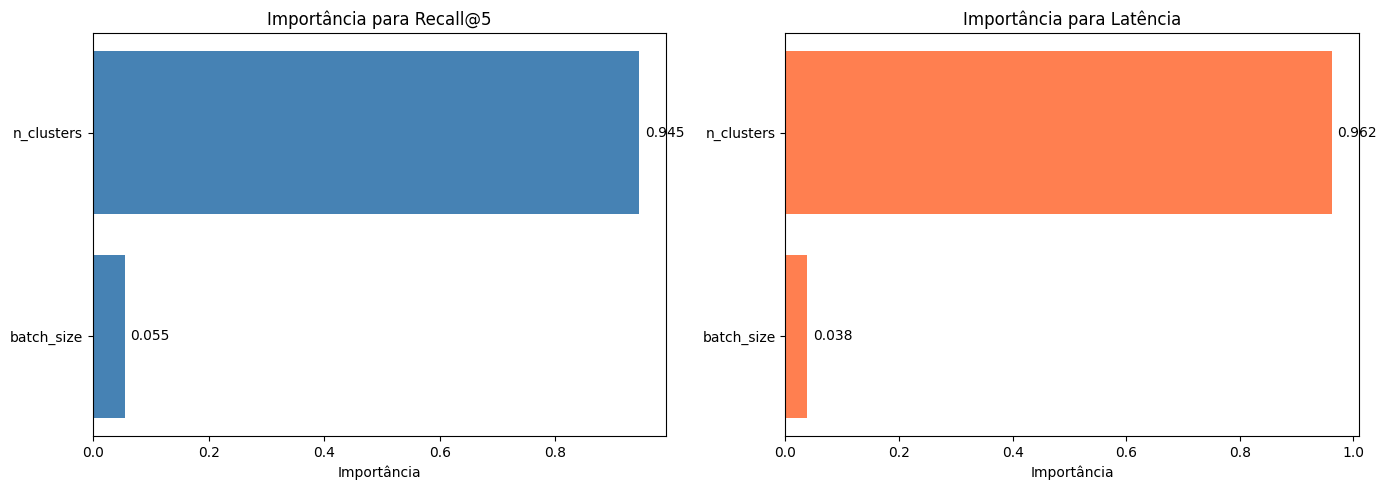


--- Importância Recall@5 ---
  n_clusters: 0.9450
  batch_size: 0.0550

--- Importância Latência ---
  n_clusters: 0.9620
  batch_size: 0.0380


In [27]:
# Importância dos hiperparâmetros por objetivo
importance_recall = optuna.importance.get_param_importances(study, target=lambda t: t.values[0])
importance_latency = optuna.importance.get_param_importances(study, target=lambda t: t.values[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

params = list(importance_recall.keys())
vals_r = list(importance_recall.values())
axes[0].barh(params, vals_r, color="steelblue")
axes[0].set_xlabel("Importância")
axes[0].set_title("Importância para Recall@5")
axes[0].invert_yaxis()
for i, v in enumerate(vals_r):
    axes[0].text(v + 0.01, i, f"{v:.3f}", va="center")

params = list(importance_latency.keys())
vals_l = list(importance_latency.values())
axes[1].barh(params, vals_l, color="coral")
axes[1].set_xlabel("Importância")
axes[1].set_title("Importância para Latência")
axes[1].invert_yaxis()
for i, v in enumerate(vals_l):
    axes[1].text(v + 0.01, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.show()

print("\n--- Importância Recall@5 ---")
for p, v in importance_recall.items():
    print(f"  {p}: {v:.4f}")

print("\n--- Importância Latência ---")
for p, v in importance_latency.items():
    print(f"  {p}: {v:.4f}")

## 6. Fronteira de Pareto — Trade-off recall vs latência

In [28]:
# Todos os trials
trials_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            "trial": t.number,
            "n_clusters": t.params["n_clusters"],
            "batch_size": t.params["batch_size"],
            "nprobe": t.params["nprobe"],
            "recall_at_5": t.values[0],
            "latency_ms": t.values[1],
            "avg_candidates": t.user_attrs.get("avg_candidates", 0),
            "pareto": t in study.best_trials,
        })

df_trials = pd.DataFrame(trials_data)

fig = px.scatter(
    df_trials,
    x="latency_ms",
    y="recall_at_5",
    color="pareto",
    size="n_clusters",
    hover_data=["n_clusters", "batch_size", "nprobe", "avg_candidates"],
    title="Fronteira de Pareto — Recall@5 vs Latência",
    labels={"latency_ms": "Latência (ms/query)", "recall_at_5": "Recall@5"},
    color_discrete_map={True: "red", False: "lightgray"},
    template="plotly_white",
)
fig.update_layout(height=500)
fig.show()

# Tabela dos pontos na fronteira de Pareto
df_pareto = df_trials[df_trials["pareto"]].sort_values("recall_at_5", ascending=False)
print("\nFronteira de Pareto (ordenado por recall):")
df_pareto[["n_clusters", "batch_size", "nprobe", "recall_at_5", "latency_ms", "avg_candidates"]]


Fronteira de Pareto (ordenado por recall):


,n_clusters,batch_size,nprobe,recall_at_5,latency_ms,avg_candidates
41,1476,8192,38,1.00000,0.201917,3191.9726
39,1517,8192,25,0.99990,0.136447,2010.8393
16,1870,4096,29,0.99988,0.120281,1606.4337
10,3931,8192,31,0.99968,0.092906,835.8398
34,1355,4096,16,0.99936,0.092904,1299.3034
44,2437,8192,17,0.99878,0.080322,798.2790
31,1533,4096,11,0.99644,0.073960,799.1262
36,1190,8192,8,0.99390,0.066577,845.4080
49,3976,8192,6,0.96040,0.058342,160.6921
38,1413,8192,2,0.85722,0.026741,177.5787


## 7. Contour plots — Interação entre parâmetros

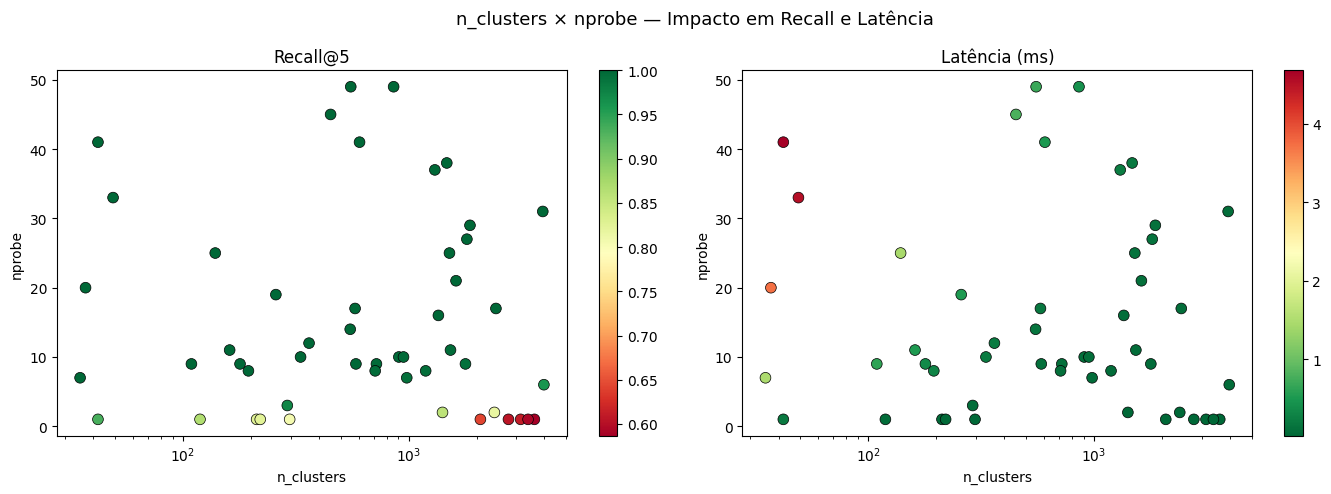

In [29]:
# Contour plots para recall e latência
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_complete = df_trials[df_trials["recall_at_5"] > 0].copy()

sc0 = axes[0].scatter(
    df_complete["n_clusters"],
    df_complete["nprobe"],
    c=df_complete["recall_at_5"],
    cmap="RdYlGn",
    s=60,
    edgecolors="k",
    linewidths=0.5,
)
axes[0].set_xlabel("n_clusters")
axes[0].set_ylabel("nprobe")
axes[0].set_title("Recall@5")
axes[0].set_xscale("log")
plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(
    df_complete["n_clusters"],
    df_complete["nprobe"],
    c=df_complete["latency_ms"],
    cmap="RdYlGn_r",
    s=60,
    edgecolors="k",
    linewidths=0.5,
)
axes[1].set_xlabel("n_clusters")
axes[1].set_ylabel("nprobe")
axes[1].set_title("Latência (ms)")
axes[1].set_xscale("log")
plt.colorbar(sc1, ax=axes[1])

plt.suptitle("n_clusters × nprobe — Impacto em Recall e Latência", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Seleção do melhor config + Validação final

Seleciona a config com **recall@5 ≥ 0.95** e menor latência, e valida o impacto na decisão de fraude.

In [30]:
# Filtrar configs com recall >= 0.95
MIN_RECALL = 0.95
df_good = df_trials[(df_trials["recall_at_5"] >= MIN_RECALL)].copy()

if len(df_good) == 0:
    print(f"Nenhuma config com recall >= {MIN_RECALL}. Relaxando para top 5 por recall...")
    df_good = df_trials.nlargest(5, "recall_at_5")

best_row = df_good.sort_values("latency_ms").iloc[0]
best_n_clusters = int(best_row["n_clusters"])
best_batch_size = int(best_row["batch_size"])
best_nprobe = int(best_row["nprobe"])

print(f"Melhor config (recall >= {MIN_RECALL}, menor latência):")
print(f"  n_clusters = {best_n_clusters}")
print(f"  batch_size = {best_batch_size}")
print(f"  nprobe     = {best_nprobe}")
print(f"  recall@5   = {best_row['recall_at_5']:.4f}")
print(f"  latency    = {best_row['latency_ms']:.2f} ms/query")

# Validação final com classificação
experiment.build_index(best_n_clusters, best_batch_size)
search_final = experiment.search(best_nprobe)
cls_final = experiment.evaluate_classification(best_nprobe)

print(f"\n--- Validação Final ---")
print(f"  Recall@5:            {search_final['recall_at_k']:.4f}")
print(f"  Latência:            {search_final['latency_ms']:.2f} ms/query")
print(f"  Candidatos médios:   {search_final['avg_candidates']:.0f}")
print(f"  Decision agreement:  {cls_final['decision_agreement']:.4f}")
print(f"  IVF rejeitados:      {cls_final['ivf_rejected']}")
print(f"  BF rejeitados:       {cls_final['bf_rejected']}")

speedup = gt_dists.shape[0]  # n_queries * full_scan vs IVF
print(f"\n  Candidatos escaneados: {search_final['avg_candidates']:.0f} / {len(X_train)} ({100*search_final['avg_candidates']/len(X_train):.2f}% do dataset)")

Melhor config (recall >= 0.95, menor latência):
  n_clusters = 3976
  batch_size = 8192
  nprobe     = 6
  recall@5   = 0.9604
  latency    = 0.06 ms/query

--- Validação Final ---
  Recall@5:            0.9604
  Latência:            0.06 ms/query
  Candidatos médios:   161
  Decision agreement:  0.9993
  IVF rejeitados:      3336
  BF rejeitados:       3339

  Candidatos escaneados: 161 / 90000 (0.18% do dataset)


## 9. Resumo da análise de sensibilidade

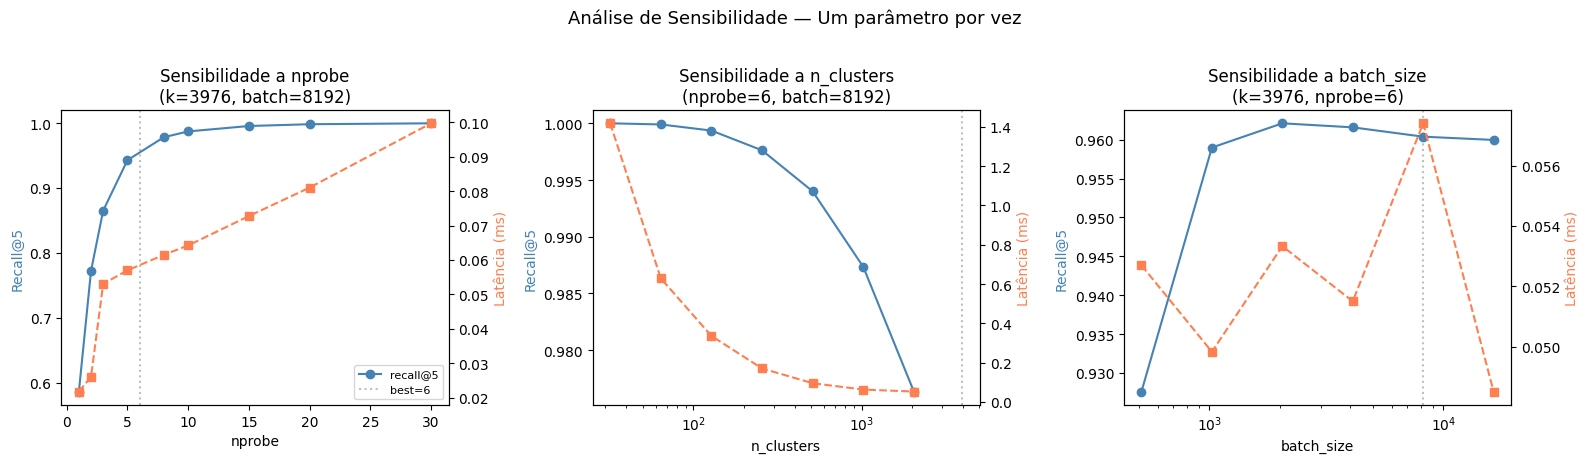

In [31]:
# Análise de sensibilidade: fixar 2 parâmetros e variar o terceiro
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1) Efeito do nprobe (fixando n_clusters e batch_size do melhor)
nprobe_range = sorted(set([1, 2, 3, 5, 8, 10, 15, 20, 30]) & set(range(1, best_n_clusters + 1)))
experiment.build_index(best_n_clusters, best_batch_size)
sens_nprobe = [experiment.search(n) for n in nprobe_range]

ax = axes[0]
ax.plot(nprobe_range, [r["recall_at_k"] for r in sens_nprobe], "o-", color="steelblue", label="recall@5")
ax.set_xlabel("nprobe")
ax.set_ylabel("Recall@5", color="steelblue")
ax2 = ax.twinx()
ax2.plot(nprobe_range, [r["latency_ms"] for r in sens_nprobe], "s--", color="coral", label="latência")
ax2.set_ylabel("Latência (ms)", color="coral")
ax.set_title(f"Sensibilidade a nprobe\n(k={best_n_clusters}, batch={best_batch_size})")
ax.axvline(best_nprobe, color="gray", linestyle=":", alpha=0.5, label=f"best={best_nprobe}")
ax.legend(loc="lower right", fontsize=8)

# 2) Efeito do n_clusters (fixando nprobe e batch_size do melhor)
k_range = [32, 64, 128, 256, 512, 1024, 2048]
sens_k = []
for k_val in k_range:
    experiment.build_index(k_val, best_batch_size)
    nprobe_capped = min(best_nprobe, k_val)
    sens_k.append(experiment.search(nprobe_capped))

ax = axes[1]
ax.plot(k_range, [r["recall_at_k"] for r in sens_k], "o-", color="steelblue")
ax.set_xlabel("n_clusters")
ax.set_ylabel("Recall@5", color="steelblue")
ax.set_xscale("log")
ax2 = ax.twinx()
ax2.plot(k_range, [r["latency_ms"] for r in sens_k], "s--", color="coral")
ax2.set_ylabel("Latência (ms)", color="coral")
ax.set_title(f"Sensibilidade a n_clusters\n(nprobe={best_nprobe}, batch={best_batch_size})")
ax.axvline(best_n_clusters, color="gray", linestyle=":", alpha=0.5)

# 3) Efeito do batch_size (fixando n_clusters e nprobe do melhor)
batch_range = [512, 1024, 2048, 4096, 8192, 16384]
sens_batch = []
for b in batch_range:
    experiment.build_index(best_n_clusters, b)
    sens_batch.append(experiment.search(best_nprobe))

ax = axes[2]
ax.plot(batch_range, [r["recall_at_k"] for r in sens_batch], "o-", color="steelblue")
ax.set_xlabel("batch_size")
ax.set_ylabel("Recall@5", color="steelblue")
ax.set_xscale("log")
ax2 = ax.twinx()
ax2.plot(batch_range, [r["latency_ms"] for r in sens_batch], "s--", color="coral")
ax2.set_ylabel("Latência (ms)", color="coral")
ax.set_title(f"Sensibilidade a batch_size\n(k={best_n_clusters}, nprobe={best_nprobe})")
ax.axvline(best_batch_size, color="gray", linestyle=":", alpha=0.5)

plt.suptitle("Análise de Sensibilidade — Um parâmetro por vez", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. Config final para exportação

Parâmetros otimizados para usar na API Go.

In [32]:
config = {
    "n_clusters": best_n_clusters,
    "batch_size": best_batch_size,
    "nprobe": best_nprobe,
    "k_neighbors": K_NEIGHBORS,
    "fraud_threshold": FRAUD_THRESHOLD,
    "recall_at_5": round(search_final["recall_at_k"], 4),
    "latency_ms": round(search_final["latency_ms"], 2),
    "decision_agreement": round(cls_final["decision_agreement"], 4),
    "optimized_on_sample_size": len(vectors),  # Tamanho da amostra usada no treinamento
    "vector_dim": vectors.shape[1],
}

print("=== CONFIG DA MELHOR RUN (otimizada em amostra) ===")
print(json.dumps(config, indent=2))

# Salvar config
config_path = Path.cwd()
if config_path.name == "notebooks":
    config_path = config_path.parent
config_path = config_path / "data" / "ivf_config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print(f"\n✓ Config salva em {config_path}")


=== CONFIG DA MELHOR RUN (otimizada em amostra) ===
{
  "n_clusters": 3976,
  "batch_size": 8192,
  "nprobe": 6,
  "k_neighbors": 5,
  "fraud_threshold": 0.6,
  "recall_at_5": 0.9604,
  "latency_ms": 0.06,
  "decision_agreement": 0.9993,
  "optimized_on_sample_size": 100000,
  "vector_dim": 14
}

✓ Config salva em /Users/luiz/repos/rbc-2026/data/ivf_config.json


## 11. Exportar índice IVF em binário para o Go

Os centroides são **treinados em amostra** (100k registros) usando os parâmetros ótimos encontrados. O índice final usa **todos os vetores do dataset completo** (3M+).

**`data/centroids.bin`**
```
[int64: n_clusters][int64: dim][float64 × n_clusters × dim]
```

**`data/vectors.bin`** (dataset COMPLETO)
```
[int64: n_vectors][int64: dim]
[float64 × n_vectors × dim]   ← todos os 3M+ vetores
[uint8  × n_vectors]          ← labels (1=fraud, 0=legit)
```

**`data/ivf_structure.bin`**
```
[int64: n_clusters]
para cada cluster:
  [int64: list_size]
  [int32 × list_size]          ← índices em vectors.bin (0-based)
```

O Go carrega `vectors.bin` uma vez na RAM, e usa `ivf_structure.bin` para saber quais índices pertencem a cada centroide.


In [33]:
import struct

data_dir = Path.cwd()
if data_dir.name == "notebooks":
    data_dir = data_dir.parent
data_dir = data_dir / "data"

print("=" * 70)
print("EXPORTANDO PARA GO: Generalizando achados para dataset completo")
print("=" * 70)

# ─── 1. Centroides: treinados em amostra (100k) com parâmetros ótimos ──────
print(f"\n[1/3] Treinando centroides (amostra: {len(X_train):,} registros)...")
experiment.build_index(best_n_clusters, best_batch_size)
centroids = experiment.centroids       # (n_clusters, dim)
n_clusters, dim = centroids.shape

centroids_path = data_dir / "centroids.bin"
with open(centroids_path, "wb") as f:
    f.write(struct.pack("<qq", n_clusters, dim))
    f.write(centroids.astype("<f8").tobytes())

print(f"   ✓ {centroids_path.name}: {centroids_path.stat().st_size / 1024:.1f} KB")
print(f"     {n_clusters} centroides × {dim} dimensões")

# ─── 2. Vetores: carrega DATASET COMPLETO (3M+) e estrutura IVF ────────────
BATCH = 10_000
inv_lists = [[] for _ in range(n_clusters)]

all_vecs_chunks = []
all_labels_list = []
n_total = 0

print(f"\n[2/3] Aplicando ao dataset completo ({DATA_PATH.name})...")
t0 = time.time()

with gzip.open(DATA_PATH, "rb") as gz:
    batch_vecs = []
    
    def _flush(batch_vecs, offset):
        """Processa um batch: atribui cada vetor ao centroide mais próximo."""
        arr = np.stack(batch_vecs)                         # (BATCH, dim)
        dists = cdist(arr, centroids)                      # (BATCH, n_clusters)
        assignments = np.argmin(dists, axis=1)             # (BATCH,)
        for local_i, c in enumerate(assignments):
            inv_lists[c].append(offset + local_i)
        all_vecs_chunks.append(arr)

    for obj in ijson.items(gz, "item"):
        vec = np.asarray(obj["vector"], dtype=np.float64)
        all_labels_list.append(np.uint8(1 if obj.get("label") == "fraud" else 0))
        batch_vecs.append(vec)

        if len(batch_vecs) == BATCH:
            _flush(batch_vecs, n_total)
            n_total += BATCH
            batch_vecs = []
            if n_total % 500_000 == 0:
                print(f"     ... {n_total:,} vetores processados")

    if batch_vecs:
        _flush(batch_vecs, n_total)
        n_total += len(batch_vecs)

all_vecs = np.concatenate(all_vecs_chunks)       # (n_total, dim)
all_labels = np.array(all_labels_list, dtype=np.uint8)
elapsed = time.time() - t0

print(f"   ✓ Dataset completo processado")
print(f"     {n_total:,} vetores em {elapsed:.1f}s ({all_vecs.nbytes/1024**2:.0f} MB)")

# ─── 3a. Salva vectors.bin: todos os vetores + labels ──────────────────────
vectors_path = data_dir / "vectors.bin"
with open(vectors_path, "wb") as f:
    f.write(struct.pack("<qq", n_total, dim))
    f.write(all_vecs.astype("<f8").tobytes())
    f.write(all_labels.tobytes())

print(f"\n[3/3] Exportando índice IVF...")
print(f"   ✓ {vectors_path.name}: {vectors_path.stat().st_size / 1024**2:.1f} MB")
print(f"     {n_total:,} vetores × {dim} dims + {n_total} labels")

# ─── 3b. Salva ivf_structure.bin: listas invertidas ───────────────────────
ivf_path = data_dir / "ivf_structure.bin"
with open(ivf_path, "wb") as f:
    f.write(struct.pack("<q", n_clusters))
    for c in range(n_clusters):
        ids = np.array(inv_lists[c], dtype="<i4")   # int32 índices
        f.write(struct.pack("<q", len(ids)))
        f.write(ids.tobytes())

sizes = [len(inv_lists[c]) for c in range(n_clusters)]
print(f"   ✓ {ivf_path.name}: {ivf_path.stat().st_size / 1024**2:.1f} MB")
print(f"     Tamanho médio das listas: {np.mean(sizes):.0f}")
print(f"     Min={np.min(sizes)}, Max={np.max(sizes)}")

# ─── Resumo ───────────────────────────────────────────────────────────────
print(f"\n" + "=" * 70)
print(f"SUCESSO! Arquivos prontos em {data_dir}/")
print(f"=" * 70)
for p in [centroids_path, vectors_path, ivf_path, data_dir / "ivf_config.json"]:
    if p.exists():
        sz = p.stat().st_size
        print(f"  {p.name:<25} {sz/1024**2:7.1f} MB  ✓")
    else:
        print(f"  {p.name:<25} FALTANDO  ✗")
print(f"\n→ Próximo passo: Carregar em cmd/api/main.go")


EXPORTANDO PARA GO: Generalizando achados para dataset completo

[1/3] Treinando centroides (amostra: 90,000 registros)...
   ✓ centroids.bin: 434.9 KB
     3976 centroides × 14 dimensões

[2/3] Aplicando ao dataset completo (references.json.gz)...
     ... 500,000 vetores processados
     ... 1,000,000 vetores processados
     ... 1,500,000 vetores processados
     ... 2,000,000 vetores processados
     ... 2,500,000 vetores processados
     ... 3,000,000 vetores processados
   ✓ Dataset completo processado
     3,000,000 vetores em 76.5s (320 MB)

[3/3] Exportando índice IVF...
   ✓ vectors.bin: 323.3 MB
     3,000,000 vetores × 14 dims + 3000000 labels
   ✓ ivf_structure.bin: 11.5 MB
     Tamanho médio das listas: 755
     Min=25, Max=2271

SUCESSO! Arquivos prontos em /Users/luiz/repos/rbc-2026/data/
  centroids.bin                 0.4 MB  ✓
  vectors.bin                 323.3 MB  ✓
  ivf_structure.bin            11.5 MB  ✓
  ivf_config.json               0.0 MB  ✓

→ Próximo passo